# step0 SELECTING A COMPANY


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Symbol_Info_extended.csv')
EUROPE= [ 'Ireland', 'Italy', 'Germany', 'Netherlands', 'Luxembourg', 'Spain', 'France']
DF_Europe= df[df['country'].isin(EUROPE)]

In [3]:
eu_companies = DF_Europe.sort_values(
    by='profit_margins',
    ascending=False
)

# step 1 DATA PREPARATION

In [4]:
columns= ['symbol', 'company_name', 'sector', 'industry', 'country', 'market_cap', 
          'return_on_assets', 'return_on_equity', 'profit_margins',
          'pe_trailing', 'price_to_book', 'revenue_growth', 'debt_to_equity', 'free_cashflow']
Europe0=DF_Europe[columns].copy()

In [5]:
#replacing infinite values with NaN
Europe0 = Europe0.replace([np.inf, -np.inf], np.nan)
#market_cap>0
Europe0=Europe0[Europe0['market_cap'] > 0]
#pe_trailing and price to book
Europe0.loc[Europe0['pe_trailing'] <= 0, 'pe_trailing'] = np.nan
Europe0.loc[Europe0['price_to_book'] <= 0, 'price_to_book'] = np.nan


# step 2 BUILD PEER GROUPS

In [6]:
#ASML
company= Europe0[Europe0['symbol']== 'ASML'].iloc[0]

#applying same data preparation on the raw data
df0=df.copy()
df0=df0[columns]
df0 = df0.replace([np.inf, -np.inf], np.nan)
df0=df0[df0['market_cap'] > 0]
df0.loc[df0['pe_trailing'] <= 0, 'pe_trailing'] = np.nan
df0.loc[df0['price_to_book'] <= 0, 'price_to_book'] = np.nan


#groupA --same industry
industry = df0[df0['industry']== company['industry']].copy()
industry=industry.sort_values('market_cap',ascending=False)
industry_top10=industry.head(10)

#groupB -- same continent
continent=Europe0.sort_values('market_cap',ascending=False)
continent_top10= continent.head(10)



#groupC -- closest market capitalization
closest=df0.copy()
closest['distance'] = abs(
    closest['market_cap'] - company['market_cap']
)
closest_top10=peer_C = closest.sort_values('distance').head(10)

In [7]:
print ('-- top 10 companies with highest market cap and same industry--')
print(industry_top10)
print ('-- top 10 companies with highest market cap and same continent--')
print(continent_top10)
print('-- top 10 companies with closest value to the ASML market cap--')
print(closest_top10)

-- top 10 companies with highest market cap and same industry--
     symbol              company_name      sector  \
237    ASML         ASML Holding N.V.  Technology   
1663   LRCX  Lam Research Corporation  Technology   
140    AMAT   Applied Materials, Inc.  Technology   
1533   KLAC           KLA Corporation  Technology   
2671    TER            Teradyne, Inc.  Technology   
927    ENTG            Entegris, Inc.  Technology   
151    AMKR    Amkor Technology, Inc.  Technology   
1969   NVMI                 Nova Ltd.  Technology   
2035   ONTO      Onto Innovation Inc.  Technology   
1091   FORM          FormFactor, Inc.  Technology   

                                 industry        country    market_cap  \
237   Semiconductor Equipment & Materials    Netherlands  6.293485e+11   
1663  Semiconductor Equipment & Materials  United States  3.818619e+11   
140   Semiconductor Equipment & Materials  United States  3.431175e+11   
1533  Semiconductor Equipment & Materials  United States

# step3 -- IS THE COMPANY PROFITABLE?

In [8]:
# Function to create comparison charts

def profitability_chart(df, metric, title):

    temp = df.dropna(subset=[metric]).copy()

    temp = temp.sort_values(metric)

    colors = [
        'red' if symbol == 'ASML'
        else 'steelblue'
        for symbol in temp['symbol']
    ]

    labels = temp['company_name'].fillna(
        temp['symbol']
    )

    plt.figure(figsize=(10,5))

    plt.bar(
        labels,
        temp[metric],
        color=colors
    )
    #ensuring that the chart accomodates negative balues and shows the 0 line
    plt.axhline( y=0, color='black', linewidth=1)

    plt.xticks(rotation=90)

    plt.title(title)

    plt.tight_layout()

    plt.show()


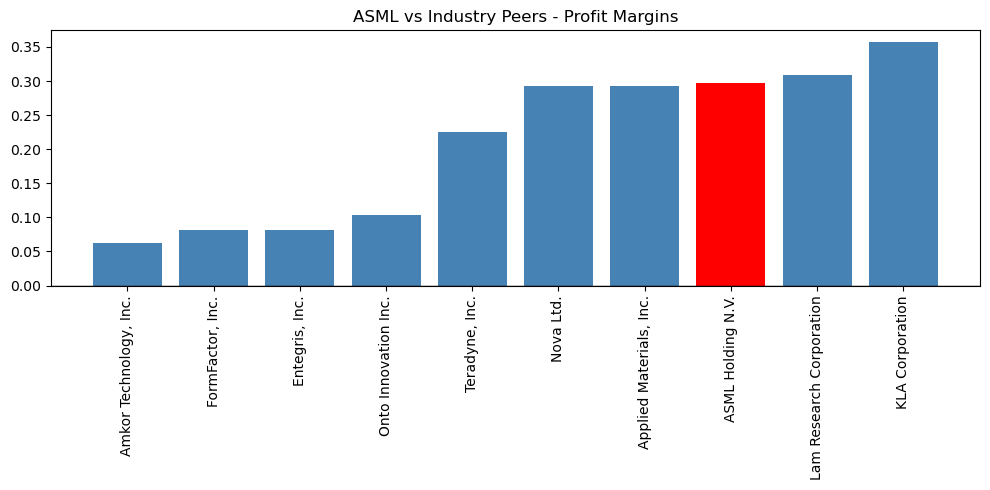

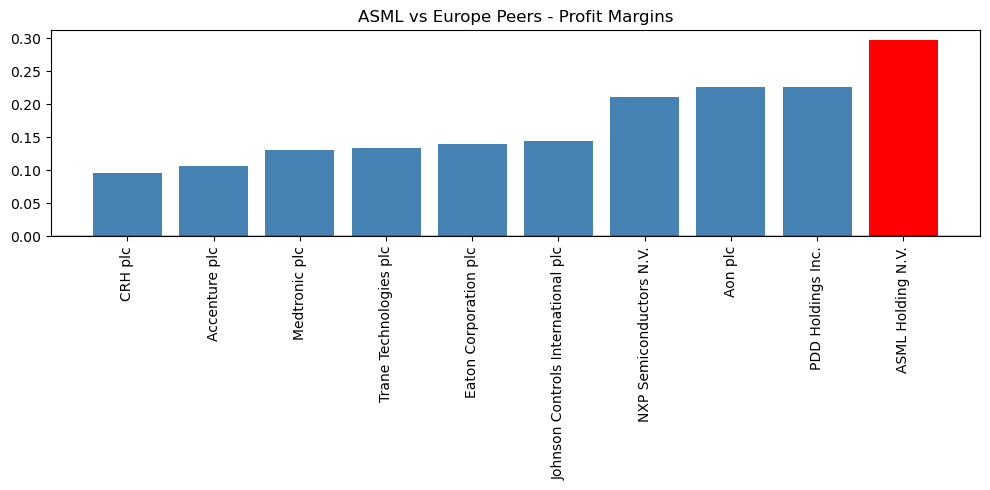

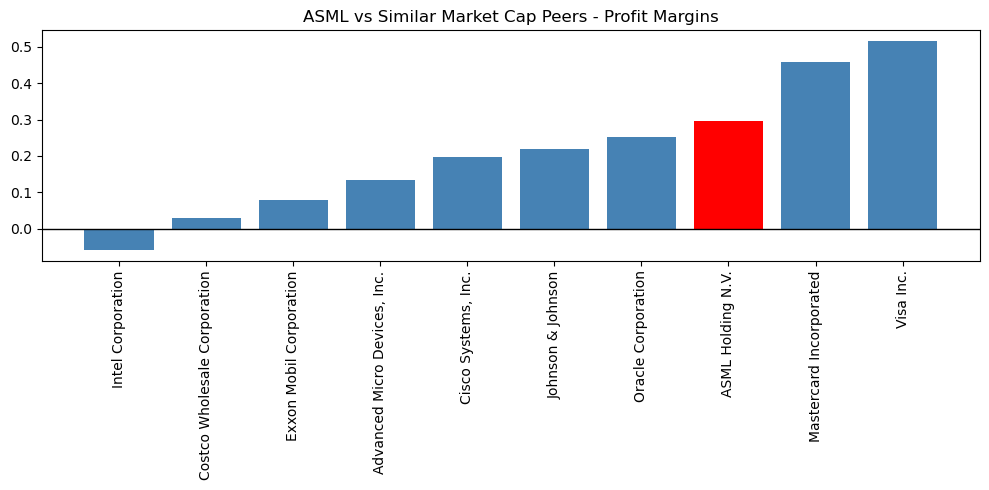

In [9]:
# comparison with industry peers
profitability_chart(
    industry_top10,
    'profit_margins',
    'ASML vs Industry Peers - Profit Margins')

#comparison with European peers
profitability_chart(
    continent_top10,
    'profit_margins',
    'ASML vs Europe Peers - Profit Margins')
#comparison with similar market cap peers
profitability_chart(
    closest_top10,
    'profit_margins',
    'ASML vs Similar Market Cap Peers - Profit Margins'
)



In [10]:
#COMPARISON BY MEDIAN PROFIT MARGINS
for name, group in [
    ('Industry', industry_top10),
    ('Europe', continent_top10),
    ('Market Cap', closest_top10)
]:

    median = group['profit_margins'].median()

    print(
        f'{name} median profit margin:',
        round(median,4)
    )
print(
    'ASML profit margin:',
    company['profit_margins'])

Industry median profit margin: 0.2588
Europe median profit margin: 0.1422
Market Cap median profit margin: 0.2076
ASML profit margin: 0.29713


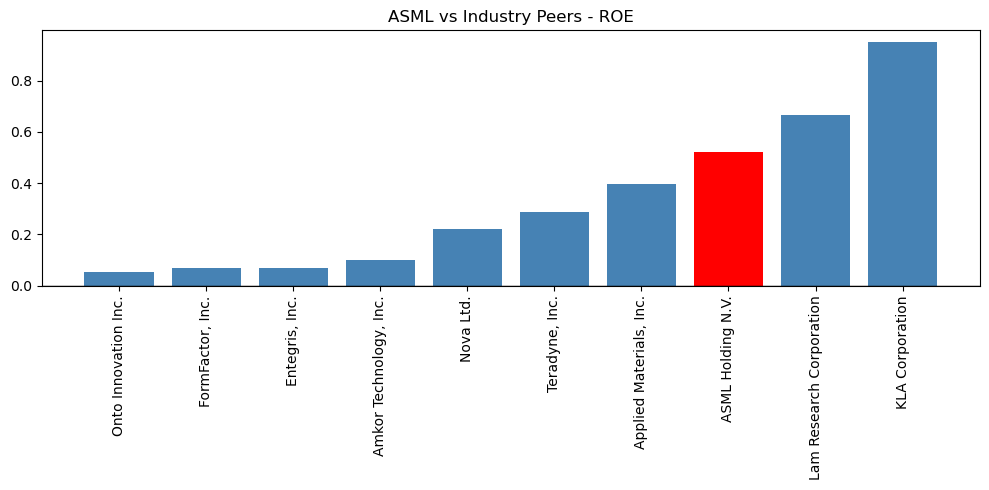

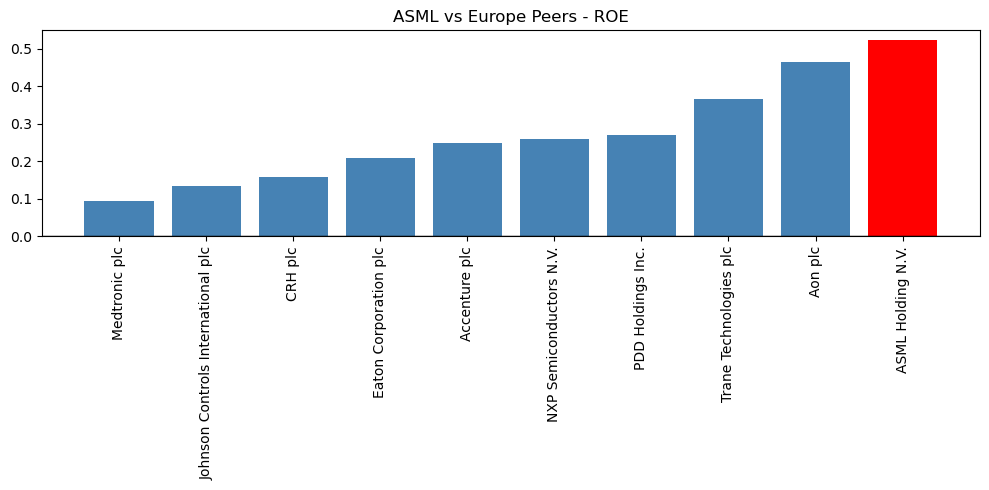

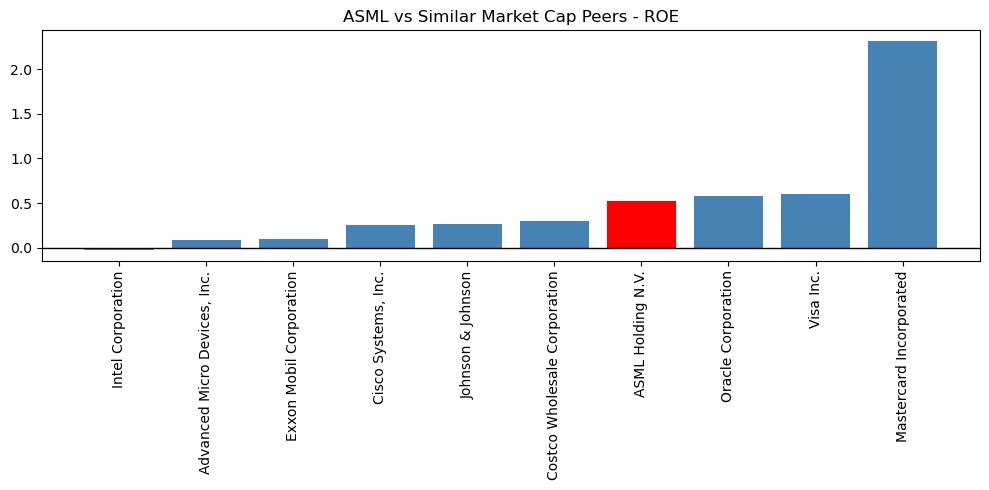

In [11]:
profitability_chart(
    industry_top10,
    'return_on_equity',
    'ASML vs Industry Peers - ROE')
profitability_chart(
    continent_top10,
    'return_on_equity',
    'ASML vs Europe Peers - ROE')
profitability_chart(
    closest_top10,
    'return_on_equity',
    'ASML vs Similar Market Cap Peers - ROE')


In [12]:
for name, group in [
    ('Industry', industry_top10),
    ('Europe', continent_top10),
    ('Market Cap', closest_top10)]:

    median = group['return_on_equity'].median()

    print(
        f'{name} median ROE:',
        round(median,4)
    )
print( 'ASML ROE:', company['return_on_equity'])

Industry median ROE: 0.255
Europe median ROE: 0.2529
Market Cap median ROE: 0.2803
ASML ROE: 0.52236


# Step 4 -- IS THE COMPANY EXPENSIVE OR CHEAP?

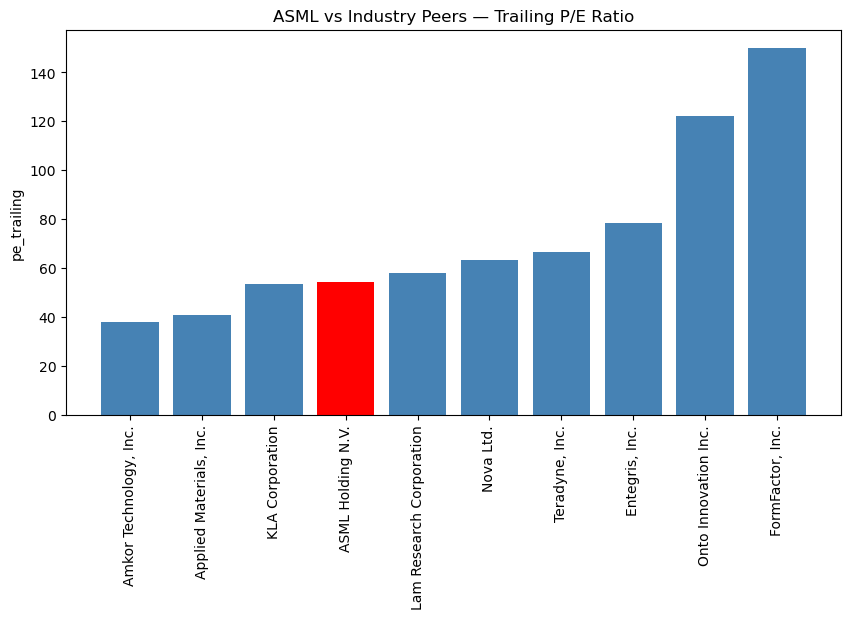

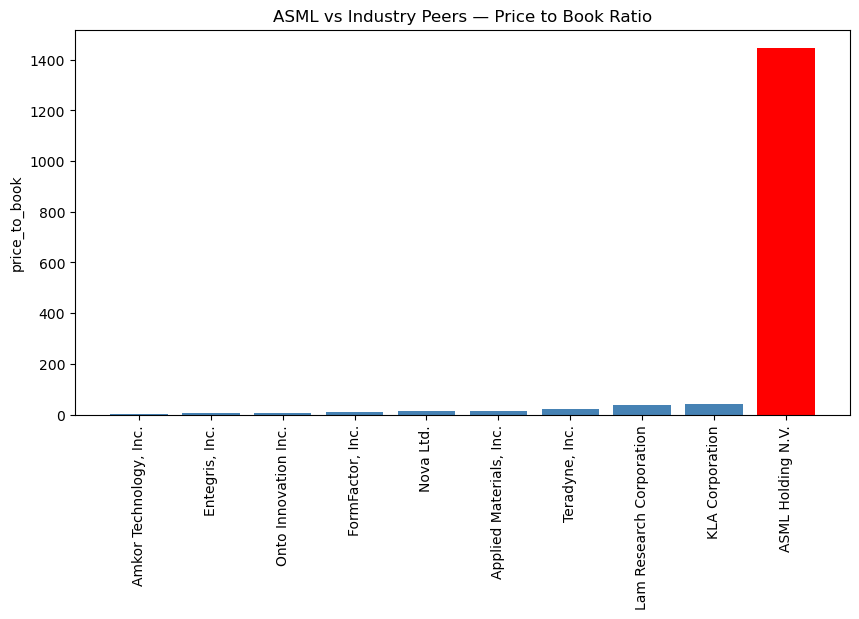

Industry median P/E: 60.42
ASML P/E: 54.34

Industry median Price-to-Book: 13.24
ASML Price-to-Book: 1446.18


In [13]:
# Function for valuation charts
def valuation_chart(df, metric, title):

    # remove missing values only for the metric used
    temp = df.dropna(subset=[metric]).copy()

    # ascending order required by assignment
    temp = temp.sort_values(metric, ascending=True)

    # highlight ASML
    colors = [
        'red' if symbol == 'ASML'
        else 'steelblue'
        for symbol in temp['symbol']
    ]

    # use company_name, otherwise symbol
    labels = temp['company_name'].fillna(temp['symbol'])

    plt.figure(figsize=(10,5))

    plt.bar(
        labels,
        temp[metric],
        color=colors
    )

    plt.xticks(rotation=90)
    plt.ylabel(metric)
    plt.title(title)

    plt.show()


# P/E chart (Group A)
valuation_chart(
    industry_top10,
    'pe_trailing',
    'ASML vs Industry Peers — Trailing P/E Ratio'
)

# Price-to-Book chart (Group A)
valuation_chart(
    industry_top10,
    'price_to_book',
    'ASML vs Industry Peers — Price to Book Ratio'
)


# median comparison for interpretation

pe_median = industry_top10['pe_trailing'].median()
pb_median = industry_top10['price_to_book'].median()

print('Industry median P/E:', round(pe_median,2))
print('ASML P/E:', round(company['pe_trailing'],2))

print()

print('Industry median Price-to-Book:', round(pb_median,2))
print('ASML Price-to-Book:', round(company['price_to_book'],2))

# step 5 -- IS THE COMPANY GROWING?

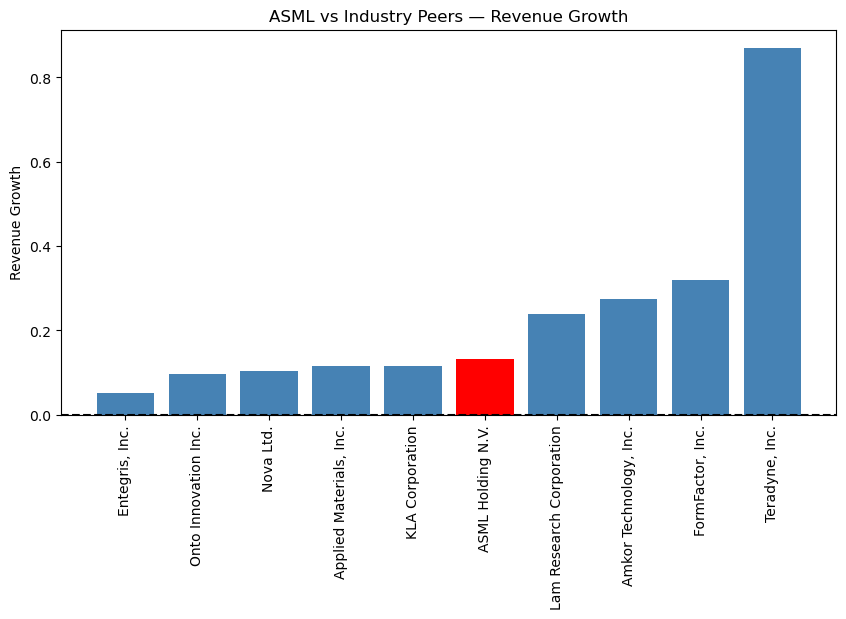

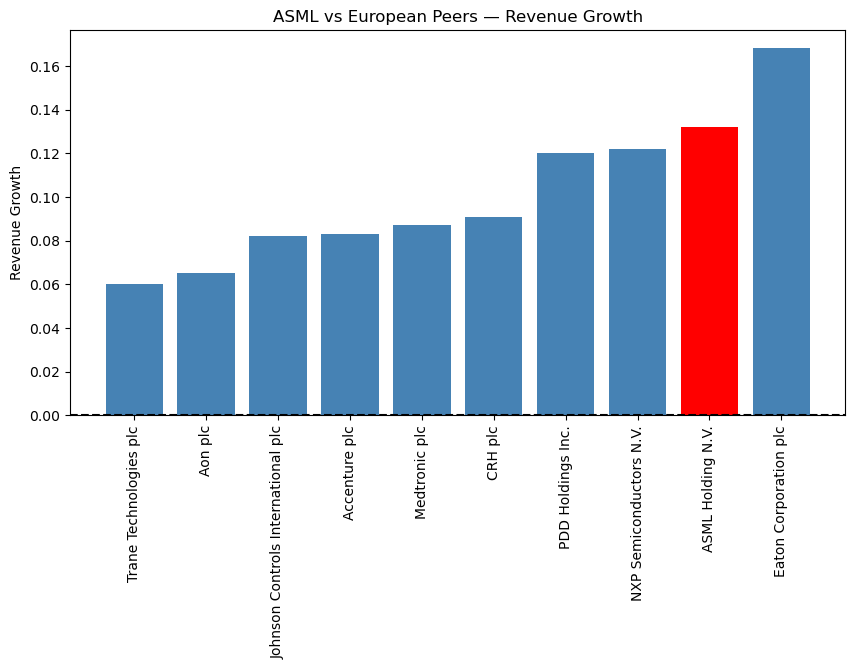

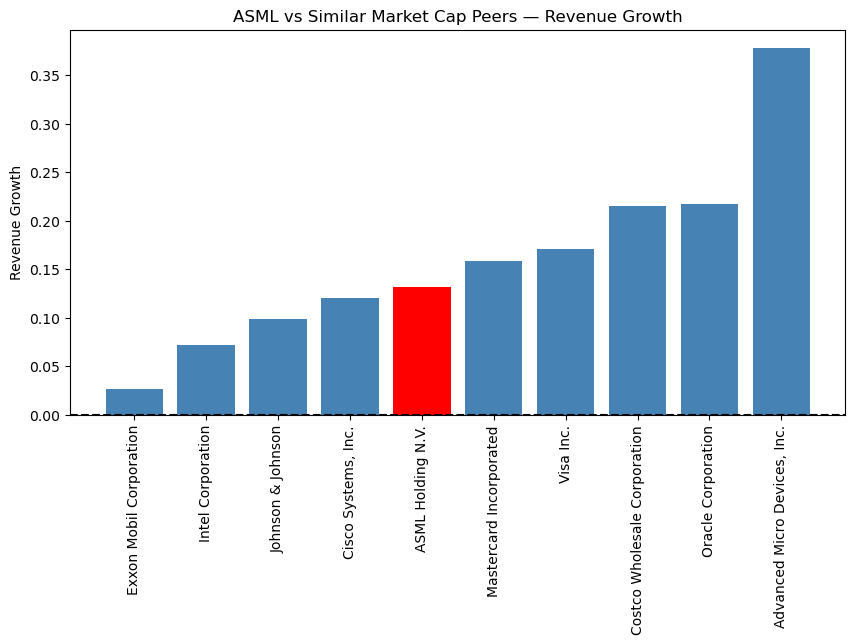

ASML Revenue Growth: 13.2 %

Industry Median: 12.35 %
Geographic Group Median: 8.9 %
Closest Market Cap Median: 14.5 %


In [14]:
#Function for evalueating
def growth_chart(df, title):

    # remove missing values only for revenue_growth
    temp = df.dropna(subset=['revenue_growth']).copy()

    # Optional outlier cap
    # Homework notes that revenue_growth can contain extreme values.
    # Cap at +/-100% growth for visualization only.
    temp['growth_capped'] = temp['revenue_growth'].clip(-1, 1)

    # sort for readability
    temp = temp.sort_values('growth_capped')

    # highlight ASML
    colors = [
        'red' if symbol == 'ASML'
        else 'steelblue'
        for symbol in temp['symbol']
    ]

    # use company_name if available
    labels = temp['company_name'].fillna(temp['symbol'])

    plt.figure(figsize=(10,5))

    plt.bar(
        labels,
        temp['growth_capped'],
        color=colors
    )

    plt.axhline(
        y=0,
        color='black',
        linestyle='--'
    )

    plt.xticks(rotation=90)
    plt.ylabel('Revenue Growth')
    plt.title(title)

    plt.show()


# Group A — Industry
growth_chart(
    industry_top10,
    'ASML vs Industry Peers — Revenue Growth'
)

# Group B — Geographic Group
growth_chart(
    continent_top10,
    'ASML vs European Peers — Revenue Growth'
)

# Group C — Closest Market Cap
growth_chart(
    closest_top10,
    'ASML vs Similar Market Cap Peers — Revenue Growth'
)


# Median comparison

industry_growth_median = industry_top10['revenue_growth'].median()
geo_growth_median = continent_top10['revenue_growth'].median()
cap_growth_median = closest_top10['revenue_growth'].median()

print('ASML Revenue Growth:',
      round(company['revenue_growth'] * 100, 2), '%')

print()

print('Industry Median:',
      round(industry_growth_median * 100, 2), '%')

print('Geographic Group Median:',
      round(geo_growth_median * 100, 2), '%')

print('Closest Market Cap Median:',
      round(cap_growth_median * 100, 2), '%')

# Step 6 -- IS THE COMPANY FINANCIALLY SOLID?

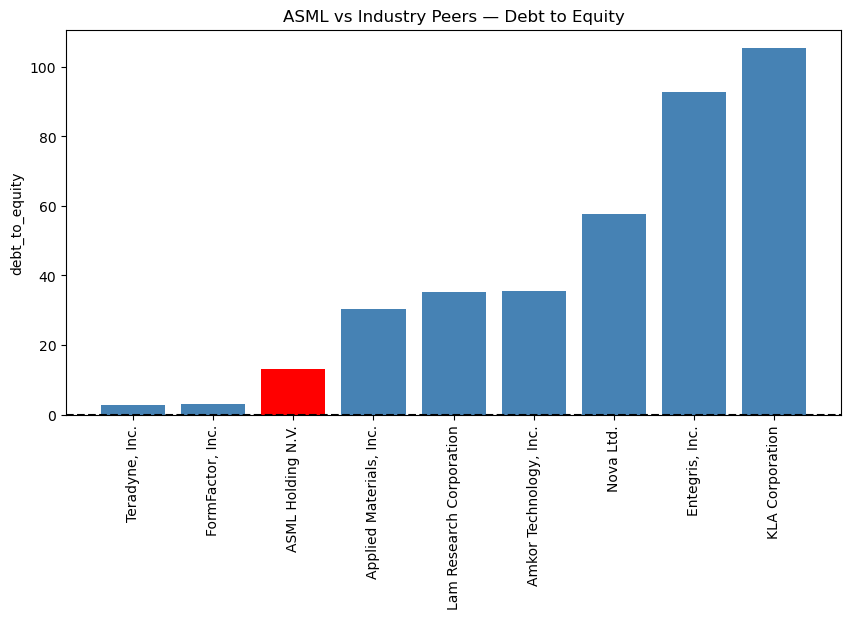

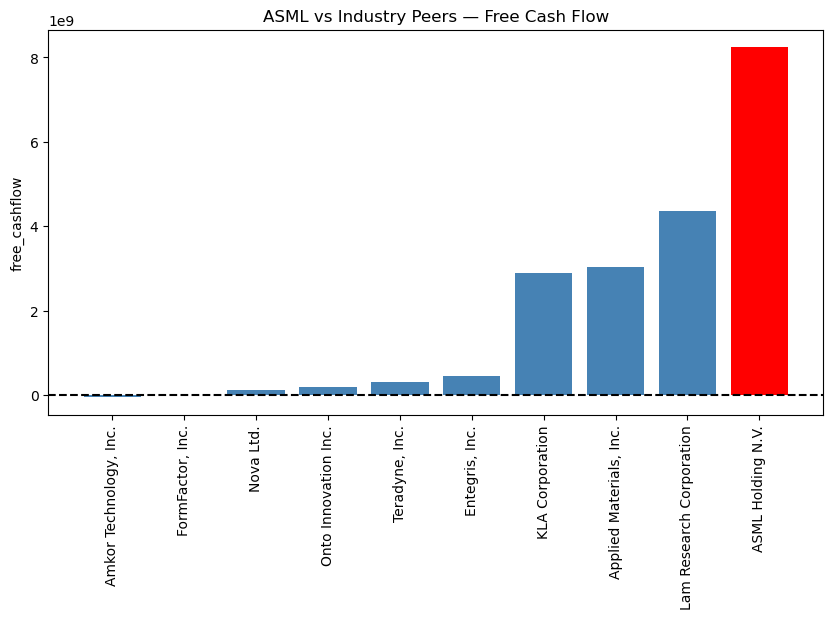

ASML Debt-to-Equity: 12.99 %
Industry Median Debt-to-Equity: 35.28 %

ASML Free Cash Flow: 8.24 Billion
Industry Median Free Cash Flow: 0.37 Billion


In [15]:
def financial_chart(df, metric, title, cap=None):

    # remove missing values only for the metric used
    temp = df.dropna(subset=[metric]).copy()

    # cap extreme outliers for visualization only
    if cap is not None:
        temp[f'{metric}_plot'] = temp[metric].clip(upper=cap)
        plot_metric = f'{metric}_plot'
    else:
        plot_metric = metric

    # sort values
    temp = temp.sort_values(plot_metric)

    # highlight ASML
    colors = [
        'red' if symbol == 'ASML'
        else 'steelblue'
        for symbol in temp['symbol']
    ]

    # use company_name if available
    labels = temp['company_name'].fillna(temp['symbol'])

    plt.figure(figsize=(10,5))

    plt.bar(
        labels,
        temp[plot_metric],
        color=colors
    )

    # useful for FCF because values may be negative
    plt.axhline(
        y=0,
        color='black',
        linestyle='--'
    )

    plt.xticks(rotation=90)
    plt.ylabel(metric)
    plt.title(title)

    plt.show()


# Debt-to-Equity (Group A only)
# Cap at 500% for visualization if extreme outliers exist
financial_chart(
    industry_top10,
    'debt_to_equity',
    'ASML vs Industry Peers — Debt to Equity',
    cap=500
)


# Free Cash Flow (Group A only)
financial_chart(
    industry_top10,
    'free_cashflow',
    'ASML vs Industry Peers — Free Cash Flow'
)


# Median comparisons

industry_debt_median = industry_top10['debt_to_equity'].median()
industry_fcf_median = industry_top10['free_cashflow'].median()

print('ASML Debt-to-Equity:',
      round(company['debt_to_equity'], 2), '%')

print('Industry Median Debt-to-Equity:',
      round(industry_debt_median, 2), '%')

print()

print('ASML Free Cash Flow:',
      round(company['free_cashflow'] / 1e9, 2),
      'Billion')

print('Industry Median Free Cash Flow:',
      round(industry_fcf_median / 1e9, 2),
      'Billion')

# COMMENTARY
the company 'ASML Holding N.V.' was chosen because looking at the top three companies in specific attributes/columns( market cap, net income, return on assets, return on equity and profit margins), the company 'ASML Holding N.V.' is consistently in the top 2.

## step 3
The median values across all three peer groups show that ASML’s profit margin is above the median in each group, indicating stronger profitability compared to its peers. The Return on Equity (ROE) analysis shows a similar pattern, with ASML’s ROE being higher than the median and approximately twice the median value in most comparisons. Overall, this suggests that ASML outperforms its peers in terms of profitability and shareholder returns.

## Step 4
ASML appears expensive relative to its industry peers. The company’s Price-to-Book ratio is above the industry median, indicating that investors are willing to pay a premium for the stock. The P/E trailing is lower than the median but it has a value that has  a positive signal. 
ASML has a stronger profitability than peers, with high profit margins and strong ROE. Therefore, the high valuation multiples are consistent with the company’s strong competitive position, profitability, and growth expectations.

## Step 5
ASML reported revenue growth of approximately 13.2%, indicating positive and strong business expansion. Compared with industry peers, European peers ASML's growth rate is above the median in most comparison groups.Differently can be said compared to companies of similar market capitalization where there is a negative difference of 1.3%. The positive growth supports the strong profitability observed and value in the previews steps. Investors are willing to pay higher valuation multiples because ASML combines strong profitability with continued revenue expansion. Overall, ASML appears to be growing faster than many comparable firms, and its growth profile is consistent with its high P/E and Price-to-Book ratios.

## Step 6
The company ASML has a debt-to-equity ratio of approximately 12.99%, which is significantly below the industry median and indicates limited reliance on debt financing. Lower leverage reduces financial risk and provides greater flexibility during economic downturns. The company also generates substantial positive free cash flow of approximately $8.24 billion, whuch is way higher than the average. Positive free cash flow indicates that ASML generates cash beyond its operating and investment requirements, supporting future growth initiatives, shareholder distributions, and strategic investments. This suggests that ASML's financial position is strong. The company does not appear to face significant balance-sheet concerns and maintains substantial financial flexibility compared with industry peers.

# missing data
No major data availability issues affected the analysis, and all key metrics required for the evaluation were available for ASML.
